In [17]:
!python train_dcft.py --r 32 --kernel_size 4 --stride 2 --batch_size 4 --lr 5e-5 --epoch 5 --out_dir elden_ring_dcft_r32_weights

Loading weights: 100%|█████████████████████| 196/196 [00:00<00:00, 15057.85it/s]
CLIPTextModel LOAD REPORT from: sd-legacy/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/hice1/ulee36/.conda/envs/dcft_env/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Injecting DCFT (k=4, s=2, dropout=0.1)...
Total DCFT Trainable Parameters: 3,438,816
Epoch 5: 100%|███████████████████| 152/152 [01:00<00:00,  2.49it/s, loss=0.1693]
DCFT Weights saved to elden_ring_dcft_r32_weights


Loading base model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /storage/ice1/2/1/ulee36/scratch/hf_cache/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /storage/ice1/2/1/ulee36/scratch/hf_cache/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Injecting DCFT layers...
Synchronizing precision and moving to GPU...
✓ DCFT weights loaded.
Generation complete! Rendering...


  0%|          | 0/30 [00:00<?, ?it/s]

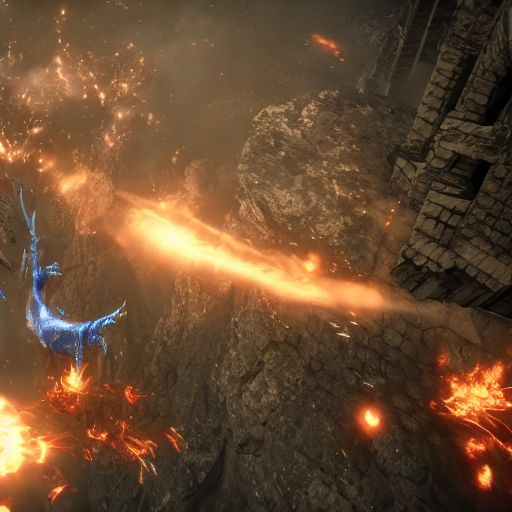

Image also saved as dcft_test_boss.png in your current directory.


In [20]:
import os
# Redirect cache to scratch to avoid quota issues
os.environ["HF_HOME"] = "/storage/ice1/2/1/ulee36/scratch/hf_cache"

import torch
import gc
import torch.nn as nn
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline

# 1. Clear VRAM
gc.collect()
torch.cuda.empty_cache()

# --- STEP 1: The Robust DCFT Architecture ---
class DCFTLinear(nn.Module):
    def __init__(self, linear_layer: nn.Linear, r=32, kernel_size=4, stride=2, dropout=0.1):
        super().__init__()
        self.in_features = linear_layer.in_features
        self.out_features = linear_layer.out_features
        
        # Store base weights (already float16 from the pipe load)
        self.register_buffer("base_weight", linear_layer.weight)
        if linear_layer.bias is not None:
            self.register_buffer("base_bias", linear_layer.bias)
        else:
            self.base_bias = None
            
        self.r = r
        self.compressed_dim = max(1, self.r // stride)
        
        # New adapter layers (initialized as float32, will be cast later)
        self.down_proj = nn.Linear(self.in_features, self.compressed_dim, bias=False)
        self.dropout = nn.Dropout(p=dropout)
        self.deconv = nn.ConvTranspose1d(1, 1, kernel_size=kernel_size, stride=stride, padding=kernel_size // 2)
        
        deconv_out_len = (self.compressed_dim - 1) * stride - 2 * (kernel_size // 2) + kernel_size
        self.up_proj = nn.Linear(deconv_out_len, self.out_features, bias=False)

    def forward(self, x):
        # Cast input to half just in case, though the model.half() should handle it
        x = x.to(self.base_weight.dtype)
        
        # Base frozen path
        base_out = F.linear(x, self.base_weight, self.base_bias)
        
        # DCFT adapter path
        orig_shape = x.shape
        x_flat = x.view(-1, self.in_features)
        subspace_x = self.dropout(self.down_proj(x_flat))
        deconv_x = self.deconv(subspace_x.unsqueeze(1)).squeeze(1)
        dcft_out = self.up_proj(deconv_x).view(*orig_shape[:-1], self.out_features)
        
        return base_out + dcft_out

def inject_dcft(module, target_modules=["to_q", "to_k", "to_v", "to_out.0"], r=16, k=4, s=2, dropout=0.1):
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and any(t in name for t in target_modules):
            setattr(module, name, DCFTLinear(child, r=r, kernel_size=k, stride=s, dropout=dropout))
        else:
            inject_dcft(child, target_modules, r, k, s, dropout)

# --- STEP 2: Load and Prepare Pipeline ---
model_id = "sd-legacy/stable-diffusion-v1-5"
device = "cuda"

print("Loading base model...")
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, # Model weights are now Half
    variant="fp16",
    low_cpu_mem_usage=True 
)

print("Injecting DCFT layers...")
inject_dcft(pipe.unet, r=32, k=4, s=2)

# --- THE FIX: Synchronize Dtypes and Device ---
print("Synchronizing precision and moving to GPU...")
pipe.unet.half() # Converts the new DCFT layers to float16
pipe.to(device)

# --- STEP 3: Load Weights ---
weights_path = "./elden_ring_dcft_r32_weights/dcft_weights.pt"
if os.path.exists(weights_path):
    # Load weights and ensure they are cast to float16 immediately
    state_dict = torch.load(weights_path, map_location=device)
    state_dict = {k: v.to(torch.float16) for k, v in state_dict.items()}
    pipe.unet.load_state_dict(state_dict, strict=False)
    print("✓ DCFT weights loaded.")
else:
    print("❌ Weights not found.")

# --- STEP 4: Generate ---
prompt = "eldenring gameplay style, third person view, player character fighting a massive dragon boss, dynamic motion, sparks, fire, cinematic camera angle"

print("Generation complete! Rendering...")
with torch.inference_mode():
    generator = torch.Generator(device).manual_seed(42)
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5, generator=generator).images[0]

# Use display() instead of image.show()
display(image)

# Also save it to your scratch folder just in case
image.save("dcft_p1.png")
print("Image also saved as dcft_test_boss.png in your current directory.")